# Electricity NPV summary

Run the electricity Monte Carlo NPV distribution, deterministic NPV, and Monte Carlo ranking summaries. The distribution table includes the number and share of simulations with non-negative NPV (NPV >= 0) and the number with negative NPV. This notebook displays figures inline only; it does not save figures or CSV files.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_deterministic import calculate_deterministic_electricity_results
from electricity.electricity_npv_monte_carlo import DEFAULT_RANDOM_SEED, DEFAULT_SAMPLE_SIZE, simulate_electricity_results
from electricity.electricity_npv_summary_figures import (
    ELECTRICITY_NPV_SCALE_OPTIONS,
    ELECTRICITY_TECHNOLOGY_LABELS,
    calculate_electricity_npv_rankings_from_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_average_rank_bars, plot_mean_npv_technology_bars


## Settings

In [4]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
TECHNOLOGIES = tuple(ELECTRICITY_TECHNOLOGY_LABELS)
NPV_SCALE = "EUR/MWh"  # "MEUR" or "EUR/MWh"

if NPV_SCALE not in ELECTRICITY_NPV_SCALE_OPTIONS:
    raise ValueError(f"Unknown NPV_SCALE: {NPV_SCALE!r}")

NPV_CONFIG = ELECTRICITY_NPV_SCALE_OPTIONS[NPV_SCALE]
NPV_METRIC_COLUMN = str(NPV_CONFIG["metric_column"])
NPV_SCALE_FACTOR = float(NPV_CONFIG["scale"])
NPV_SUMMARY_COLUMN = str(NPV_CONFIG["summary_column"])
NPV_AXIS_LABEL = str(NPV_CONFIG["axis_label"])
NPV_RANKING_LABEL = str(NPV_CONFIG["ranking_label"])

pd.options.display.float_format = "{:,.3f}".format


## Monte Carlo NPV distribution

,label,npv_eur_per_mwh,median,p05,p95,non_negative_npv_count,negative_npv_count,non_negative_npv_share
7,PV,6.563,6.564,3.753,9.396,100000,0,1.000
6,Wind Onshore,5.841,5.838,1.411,10.286,99859,141,0.999
5,Wind Offshore,3.097,3.115,-2.573,8.741,74896,25104,0.749
2,CCGT,-10.840,-9.910,-26.967,2.076,10627,89373,0.106
4,Nuclear,-13.209,-13.167,-25.902,-0.564,2953,97047,0.030
3,CCGT + CCS,-14.139,-13.120,-33.020,1.198,7254,92746,0.073
0,Hard coal,-24.276,-24.078,-29.082,-20.134,0,100000,0.000
1,Hard coal + CCS,-26.154,-26.169,-35.626,-16.789,0,100000,0.000
8,Biogas,-104.637,-104.632,-118.403,-90.800,0,100000,0.000


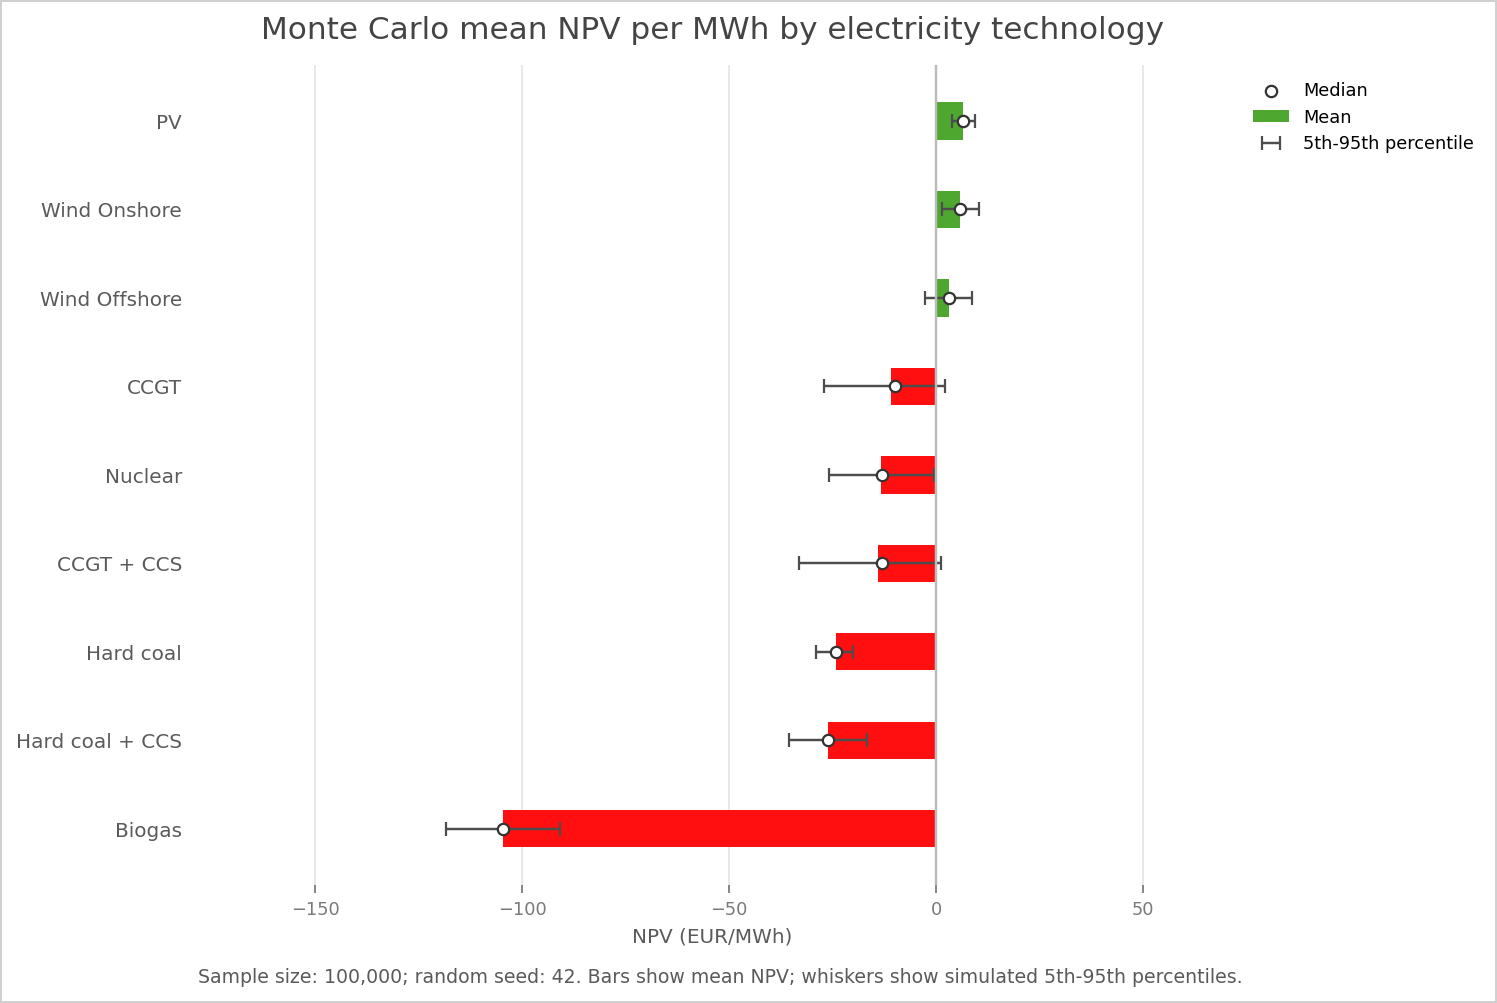

In [5]:
monte_carlo_results = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=TECHNOLOGIES,
)

mc_summary_rows = []
for technology, results in monte_carlo_results.items():
    values = np.asarray(results[NPV_METRIC_COLUMN], dtype=float) / NPV_SCALE_FACTOR
    mc_summary_rows.append(
        {
            "label": ELECTRICITY_TECHNOLOGY_LABELS.get(technology, technology),
            NPV_SUMMARY_COLUMN: values.mean(),
            "median": np.median(values),
            "p05": np.percentile(values, 5),
            "p95": np.percentile(values, 95),
            **summarize_metric_signs(values),
        }
    )
mc_summary = pd.DataFrame(mc_summary_rows).sort_values(NPV_SUMMARY_COLUMN, ascending=False)
mc_summary_by_label = mc_summary.set_index("label")

display(mc_summary)
plot_mean_npv_technology_bars(
    values_million_eur=mc_summary_by_label[NPV_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Monte Carlo mean {NPV_RANKING_LABEL} by electricity technology",
    median_values_million_eur=mc_summary_by_label["median"].to_dict(),
    lower_values_million_eur=mc_summary_by_label["p05"].to_dict(),
    upper_values_million_eur=mc_summary_by_label["p95"].to_dict(),
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    x_axis_label=NPV_AXIS_LABEL,
)
plt.show()


## Deterministic NPV

,label,npv_eur_per_mwh
7,PV,6.716
6,Wind Onshore,6.113
5,Wind Offshore,3.335
2,CCGT,-10.673
4,Nuclear,-13.067
3,CCGT + CCS,-14.097
0,Hard coal,-23.974
1,Hard coal + CCS,-25.549
8,Biogas,-103.563


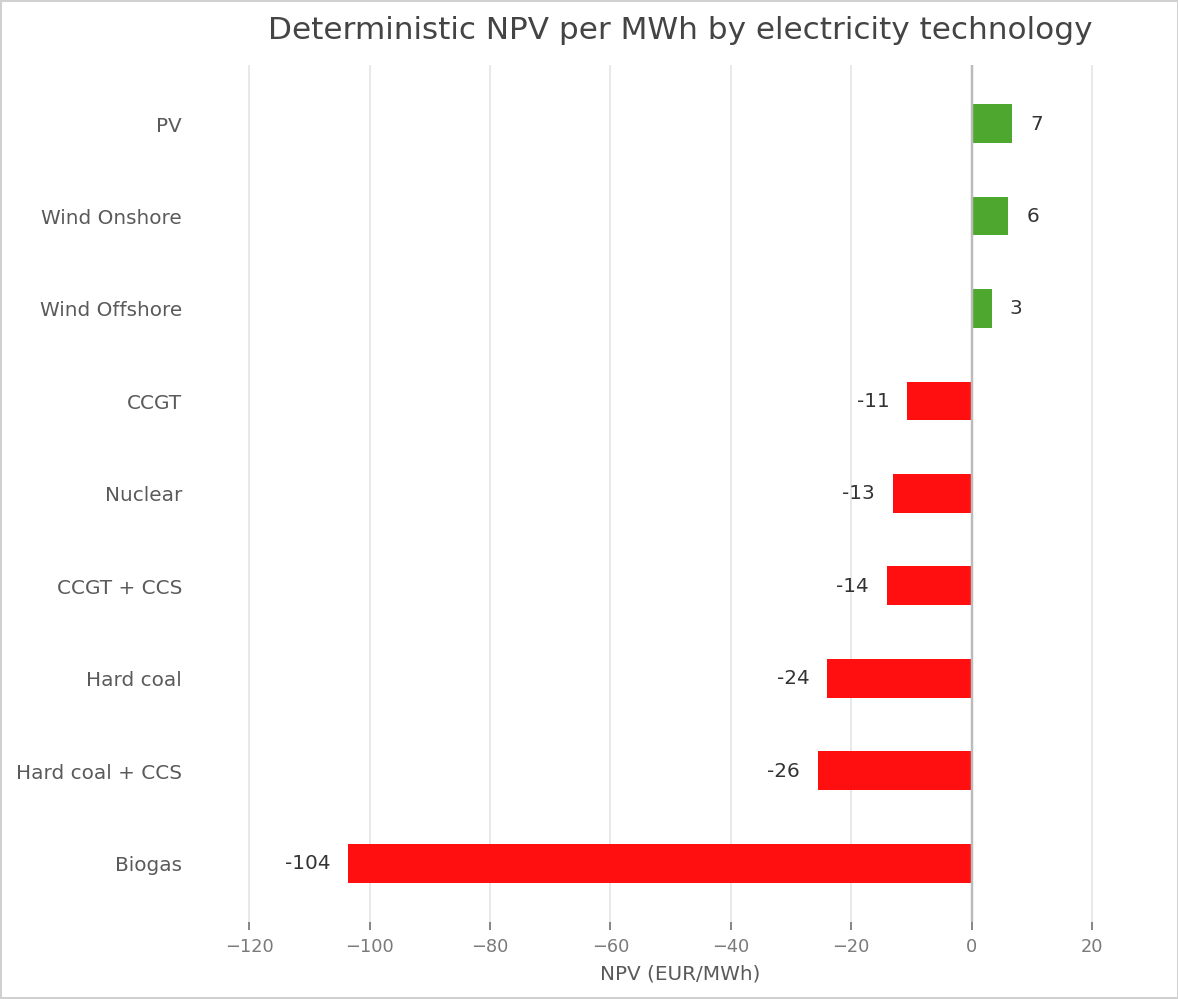

In [6]:
deterministic_results = calculate_deterministic_electricity_results(technologies=TECHNOLOGIES)
det_summary_rows = []
for technology, results in deterministic_results.items():
    det_summary_rows.append(
        {
            "label": ELECTRICITY_TECHNOLOGY_LABELS.get(technology, technology),
            NPV_SUMMARY_COLUMN: float(np.asarray(results[NPV_METRIC_COLUMN]).item()) / NPV_SCALE_FACTOR,
        }
    )
det_summary = pd.DataFrame(det_summary_rows).sort_values(NPV_SUMMARY_COLUMN, ascending=False)

display(det_summary)
plot_mean_npv_technology_bars(
    values_million_eur=det_summary.set_index("label")[NPV_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Deterministic {NPV_RANKING_LABEL} by electricity technology",
    x_axis_label=NPV_AXIS_LABEL,
)
plt.show()


## Monte Carlo NPV ranking

,Technology,Average rank,Probability rank 1,Probability top 3,Simulations
0,PV,1.660,0.470,0.997,100000
1,Wind Onshore,1.892,0.378,0.986,100000
2,Wind Offshore,2.609,0.150,0.917,100000
3,CCGT,4.644,0.001,0.050,100000
4,Nuclear,5.272,0.000,0.020,100000
5,CCGT + CCS,5.671,0.002,0.030,100000
6,Hard coal,6.998,0.000,0.000,100000
7,Hard coal + CCS,7.253,0.000,0.000,100000
8,Biogas,9.000,0.000,0.000,100000


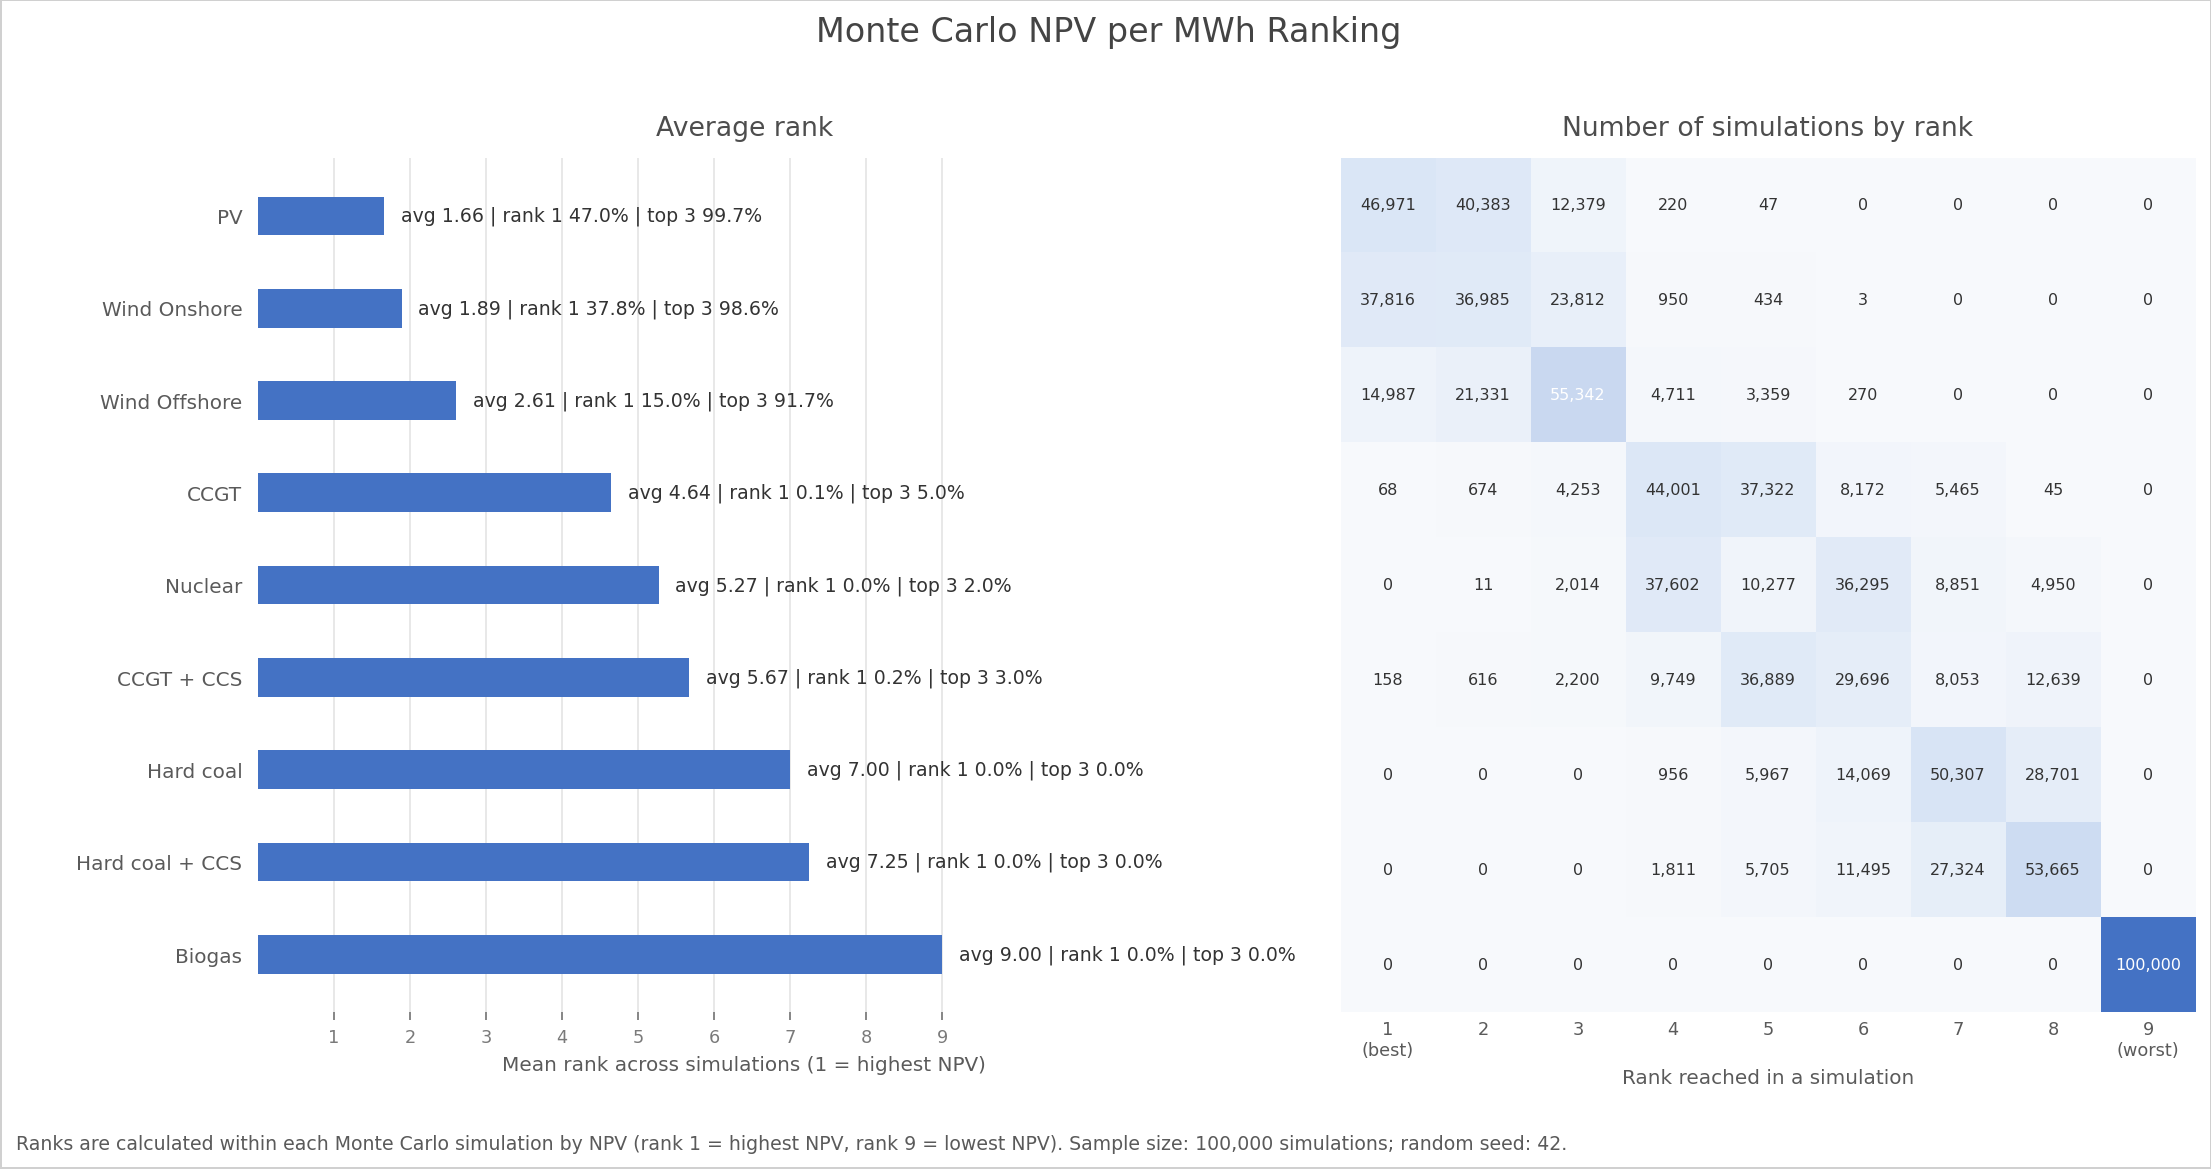

In [7]:
ranking_raw, ranking_summary = calculate_electricity_npv_rankings_from_results(
    results=monte_carlo_results,
    sector_name="Electricity",
    npv_scale=NPV_SCALE,
)

ranking_summary_for_plot = ranking_summary.assign(
    display_label=ranking_summary["technology"].map(ELECTRICITY_TECHNOLOGY_LABELS).fillna(ranking_summary["technology"])
)
rank_table = (
    ranking_summary_for_plot.rename(columns={"display_label": "Technology"})
    .loc[:, ["Technology", "average_rank", "probability_rank_1", "probability_top_3", "n_simulations"]]
    .rename(
        columns={
            "average_rank": "Average rank",
            "probability_rank_1": "Probability rank 1",
            "probability_top_3": "Probability top 3",
            "n_simulations": "Simulations",
        }
    )
)
display(rank_table)
plot_average_rank_bars(
    ranking_summary=ranking_summary_for_plot,
    output_path=None,
    title=f"Monte Carlo {NPV_RANKING_LABEL} Ranking",
    random_seed=RANDOM_SEED,
)
plt.show()
